# Problem 02 — Loan Approval Screening
### Binary Classification with Logistic Regression

**Objective:** Build and evaluate a Logistic Regression model to predict `target` (1 = positive/event class, 0 = negative/non-event class) from six applicant features.

**Dataset:** `dataset_02_loan_approval_screening.csv` — 1,000 rows, 6 predictors + target.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, roc_curve
)

RANDOM_STATE = 42
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
np.random.seed(RANDOM_STATE)


## 2. Load Data and Inspect Variables



In [2]:
df = pd.read_csv(r"C:\Users\NIKHIL JAISWAL\Videos\Loan_approval_screening\dataset\dataset_02_loan_approval_screening.csv")
print("Shape:", df.shape)
df.head(10)


Shape: (1000, 7)


,income_monthly,credit_score,debt_to_income,employment_years,loan_amount,prior_defaults,target
0,183.46,826.0,91.27,12.31,316.64,5,0
1,210.10,664.0,93.23,6.05,122.07,2,1
2,58.07,594.0,277.85,1.05,170.48,4,0
3,165.98,724.0,97.53,0.00,146.82,2,1
4,77.82,600.0,39.69,8.24,213.94,3,0
5,50.12,725.0,352.42,3.55,122.21,1,0
6,40.77,695.0,125.73,5.39,637.47,1,1
7,141.93,624.0,126.37,4.98,305.24,1,1
8,304.53,690.0,91.85,5.76,97.28,5,1
9,419.58,610.0,11.45,7.38,59.06,1,1


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   income_monthly    1000 non-null   float64
 1   credit_score      1000 non-null   float64
 2   debt_to_income    1000 non-null   float64
 3   employment_years  1000 non-null   float64
 4   loan_amount       1000 non-null   float64
 5   prior_defaults    1000 non-null   int64  
 6   target            1000 non-null   int64  
dtypes: float64(5), int64(2)
memory usage: 54.8 KB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
income_monthly,1000.0,187.52778,142.348587,19.22,88.630,147.915,236.3700,1011.22
credit_score,1000.0,679.69400,67.436712,485.00,636.000,680.000,725.0000,850.00
debt_to_income,1000.0,184.80745,136.389002,11.45,88.495,145.615,237.5700,1095.03
employment_years,1000.0,5.22747,3.708741,0.00,2.305,4.995,7.6925,17.41
loan_amount,1000.0,190.72671,149.615795,15.06,93.770,148.655,244.9525,1283.08
prior_defaults,1000.0,2.93900,1.718206,0.00,2.000,3.000,4.0000,10.00
target,1000.0,0.50000,0.500250,0.00,0.000,0.500,1.0000,1.00


## 3. Data Quality Checks



In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal duplicate rows:", df.duplicated().sum())
print("\nClass balance (target):")
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True).round(3))


Missing values per column:
income_monthly      0
credit_score        0
debt_to_income      0
employment_years    0
loan_amount         0
prior_defaults      0
target              0
dtype: int64

Total duplicate rows: 0

Class balance (target):
target
0    500
1    500
Name: count, dtype: int64
target
0    0.5
1    0.5
Name: proportion, dtype: float64


In [6]:
# Range / sanity checks
numeric_cols = ["income_monthly","credit_score","debt_to_income",
                 "employment_years","loan_amount","prior_defaults"]
print("Negative-value counts (should be 0 for all):")
print((df[numeric_cols] < 0).sum())
print("\nMin / Max per feature:")
print(df[numeric_cols].agg(["min","max"]).T)


Negative-value counts (should be 0 for all):
income_monthly      0
credit_score        0
debt_to_income      0
employment_years    0
loan_amount         0
prior_defaults      0
dtype: int64

Min / Max per feature:
                     min      max
income_monthly     19.22  1011.22
credit_score      485.00   850.00
debt_to_income     11.45  1095.03
employment_years    0.00    17.41
loan_amount        15.06  1283.08
prior_defaults      0.00    10.00


**Findings:**



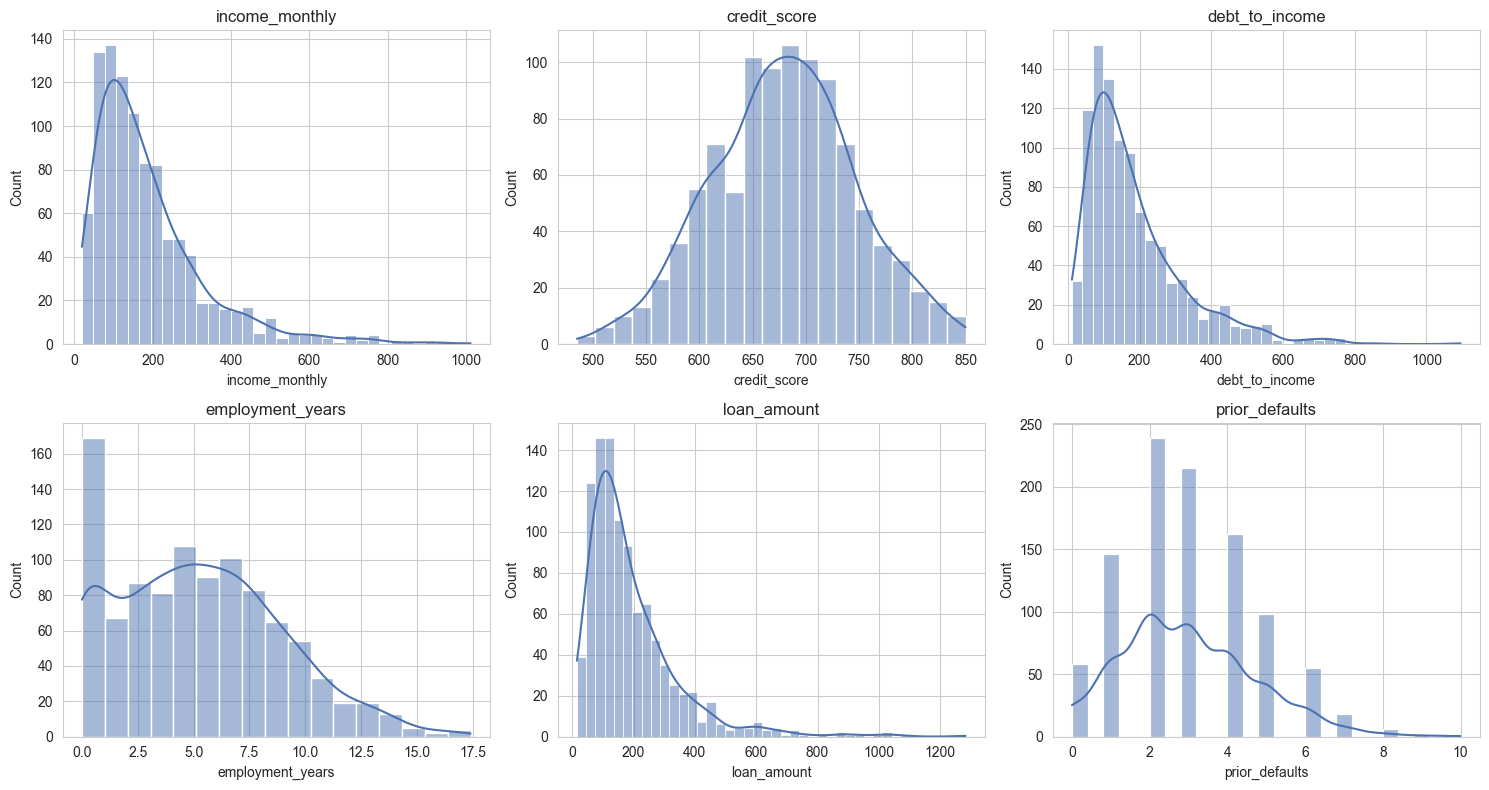

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()


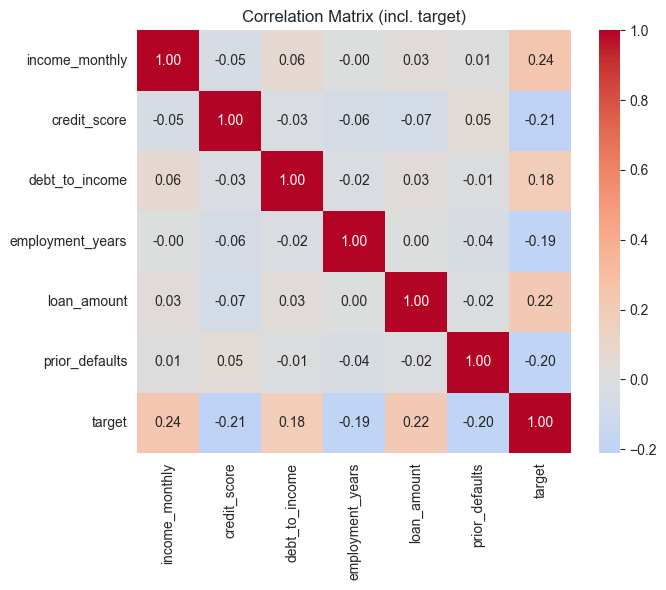

target              1.000000
income_monthly      0.238488
loan_amount         0.215031
debt_to_income      0.181712
employment_years   -0.192515
prior_defaults     -0.198562
credit_score       -0.211029
Name: target, dtype: float64

In [8]:
corr = df[numeric_cols + ["target"]].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (incl. target)")
plt.tight_layout()
plt.show()
corr["target"].sort_values(ascending=False)


## 4. Train/Test Split (Leakage-Safe)



In [9]:
X = df[numeric_cols].copy()
y = df["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


Train shape: (800, 6)  Test shape: (200, 6)
Train class balance:
 target
1    0.5
0    0.5
Name: proportion, dtype: float64
Test class balance:
 target
1    0.5
0    0.5
Name: proportion, dtype: float64


## 5. Preprocessing



In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=numeric_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=numeric_cols, index=X_test.index)
X_train_scaled.describe().T[["mean","std"]]


,mean,std
income_monthly,2.220446e-17,1.000626
credit_score,6.861178e-16,1.000626
debt_to_income,1.321165e-16,1.000626
employment_years,2.275957e-16,1.000626
loan_amount,2.220446e-16,1.000626
prior_defaults,7.993606e-17,1.000626


## 6. Baseline Model



In [11]:
baseline = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
baseline.fit(X_train_scaled, y_train)
y_pred_base = baseline.predict(X_test_scaled)
y_proba_base = baseline.predict_proba(X_test_scaled)[:, 1]

print("Baseline (stratified dummy) performance:")
print("Accuracy :", round(accuracy_score(y_test, y_pred_base), 3))
print("F1       :", round(f1_score(y_test, y_pred_base), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_base), 3))


Baseline (stratified dummy) performance:
Accuracy : 0.5
F1       : 0.505
ROC-AUC  : 0.5


## 7. Logistic Regression — Training


In [12]:
log_reg = LogisticRegression(
    solver="lbfgs",
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_STATE
)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
print("Model trained.")
print("Intercept:", log_reg.intercept_[0].round(4))


Model trained.
Intercept: 0.0495


## 8. Evaluation

We report Accuracy, Precision, Recall, F1-score and ROC-AUC on the held-out test set (default 0.5 decision threshold), plus the confusion matrix and ROC curve.


In [13]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1-score","ROC-AUC"],
    "Logistic Regression": [acc, prec, rec, f1, auc],
    "Baseline (Dummy)": [
        accuracy_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_base),
        roc_auc_score(y_test, y_proba_base)
    ]
}).round(3)
metrics_table


,Metric,Logistic Regression,Baseline (Dummy)
0,Accuracy,0.705,0.500
1,Precision,0.688,0.500
2,Recall,0.750,0.510
3,F1-score,0.718,0.505
4,ROC-AUC,0.782,0.500


                      Predicted 0  Predicted 1
Actual 0 (non-event)           66           34
Actual 1 (event)               25           75


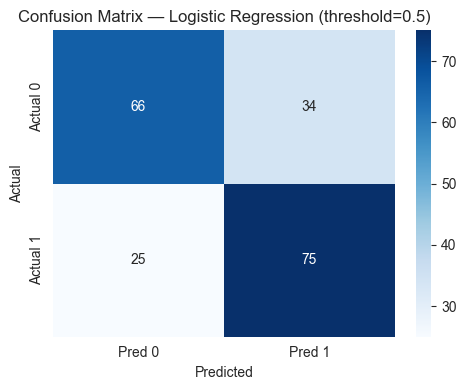


Classification report:

               precision    recall  f1-score   support

0 (non-event)       0.73      0.66      0.69       100
    1 (event)       0.69      0.75      0.72       100

     accuracy                           0.70       200
    macro avg       0.71      0.71      0.70       200
 weighted avg       0.71      0.70      0.70       200



In [14]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm,
                      index=["Actual 0 (non-event)","Actual 1 (event)"],
                      columns=["Predicted 0","Predicted 1"])
print(cm_df)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0","Pred 1"], yticklabels=["Actual 0","Actual 1"])
plt.title("Confusion Matrix — Logistic Regression (threshold=0.5)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=["0 (non-event)","1 (event)"]))


In [15]:
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted 0): {tn}")
print(f"False Positives (predicted 1, actually 0): {fp}")
print(f"False Negatives (predicted 0, actually 1): {fn}")
print(f"True Positives  (correctly predicted 1): {tp}")


True Negatives  (correctly predicted 0): 66
False Positives (predicted 1, actually 0): 34
False Negatives (predicted 0, actually 1): 25
True Positives  (correctly predicted 1): 75


**Confusion matrix interpretation:**
- **True Positives / True Negatives** are the applications the model classified correctly on both sides.
- **False Positives** (predicted class 1 but actually class 0) represent cases where the model flags the event/risk class when it should not have — in a loan-screening context, if `target=1` denotes higher risk, this is an applicant being **wrongly flagged as risky**, which could cause an otherwise-good applicant to be declined or subjected to extra scrutiny.
- **False Negatives** (predicted class 0 but actually class 1) represent the model **missing** a true event/risk case — in a risk-screening context this is the more costly error type, since a risky applicant would be approved.
- Given this asymmetry, if this model were deployed as a real screening tool, the decision threshold (currently 0.5) should be tuned according to the relative business cost of False Positives vs. False Negatives, rather than left at the default.


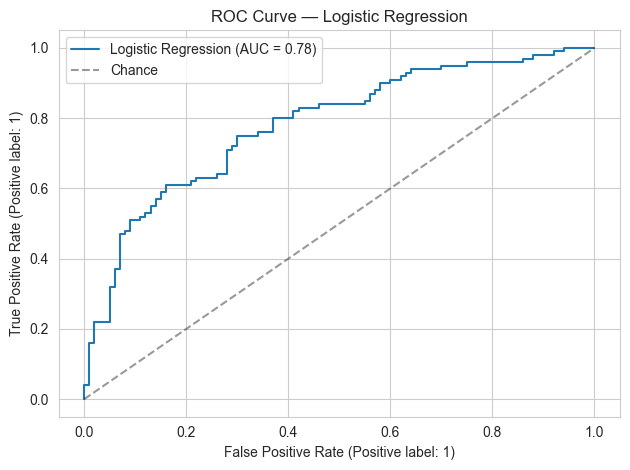

In [16]:
RocCurveDisplay.from_predictions(y_test, y_proba, name="Logistic Regression")
plt.plot([0,1],[0,1],"k--", alpha=0.4, label="Chance")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Coefficient / Feature-Effect Interpretation



In [17]:
coef_table = pd.DataFrame({
    "Feature": numeric_cols,
    "Coefficient (log-odds / 1 SD)": log_reg.coef_[0],
    "Odds Ratio (per 1 SD)": np.exp(log_reg.coef_[0])
}).sort_values("Coefficient (log-odds / 1 SD)", ascending=False).reset_index(drop=True)
coef_table


,Feature,Coefficient (log-odds / 1 SD),Odds Ratio (per 1 SD)
0,loan_amount,0.594257,1.811685
1,income_monthly,0.585169,1.795295
2,debt_to_income,0.434201,1.543729
3,prior_defaults,-0.515767,0.597043
4,credit_score,-0.524946,0.591587
5,employment_years,-0.608818,0.543994


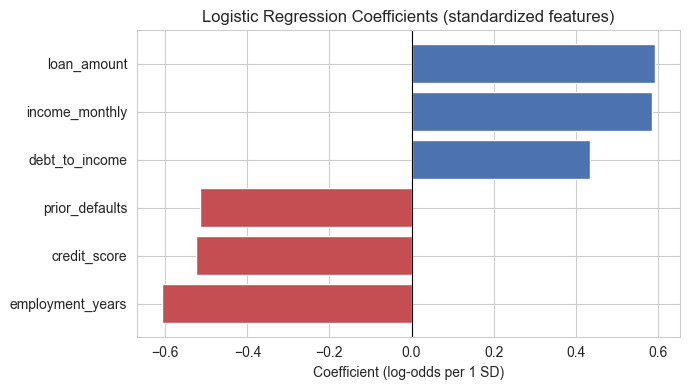

In [18]:
plt.figure(figsize=(7,4))
order = coef_table.sort_values("Coefficient (log-odds / 1 SD)")
colors = ["#C44E52" if c < 0 else "#4C72B0" for c in order["Coefficient (log-odds / 1 SD)"]]
plt.barh(order["Feature"], order["Coefficient (log-odds / 1 SD)"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression Coefficients (standardized features)")
plt.xlabel("Coefficient (log-odds per 1 SD)")
plt.tight_layout()
plt.show()


**Reading the coefficients (empirical, based on this dataset):**

**Practical / domain caveat:**


## 10. Error / Misclassification Analysis


In [19]:
errors = X_test.copy()
errors["actual"] = y_test.values
errors["predicted"] = y_pred
errors["predicted_proba"] = y_proba.round(3)
misclassified = errors[errors["actual"] != errors["predicted"]]
print(f"Total misclassified: {len(misclassified)} out of {len(errors)} ({len(misclassified)/len(errors):.1%})")
misclassified.sort_values("predicted_proba").head(10)


Total misclassified: 59 out of 200 (29.5%)


,income_monthly,credit_score,debt_to_income,employment_years,loan_amount,prior_defaults,actual,predicted,predicted_proba
986,192.90,771.0,94.50,6.32,28.22,4,1,0,0.115
658,87.54,631.0,114.42,10.45,50.22,3,1,0,0.167
72,235.26,785.0,70.69,7.34,142.78,3,1,0,0.187
533,164.08,719.0,207.32,6.76,53.75,4,1,0,0.206
301,43.80,773.0,142.48,5.66,281.46,3,1,0,0.249
356,125.34,671.0,51.97,6.51,123.03,3,1,0,0.262
505,134.93,708.0,66.96,5.25,116.51,2,1,0,0.317
551,67.85,754.0,442.99,6.21,167.04,4,1,0,0.329
806,393.36,696.0,42.12,10.78,234.97,4,1,0,0.331
746,126.53,704.0,145.92,0.89,118.09,5,1,0,0.339


In [20]:
print("Feature averages: correctly classified vs. misclassified")
correctly = errors[errors["actual"] == errors["predicted"]]
comparison = pd.DataFrame({
    "Correctly classified (mean)": correctly[numeric_cols].mean(),
    "Misclassified (mean)": misclassified[numeric_cols].mean()
}).round(2)
comparison


Feature averages: correctly classified vs. misclassified


,Correctly classified (mean),Misclassified (mean)
income_monthly,210.00,172.04
credit_score,678.84,671.39
debt_to_income,202.33,199.52
employment_years,5.34,5.06
loan_amount,179.76,166.78
prior_defaults,2.72,2.68


## Limitations, Generalization Risks and Possible Improvements


## 11. Conclusion

The Logistic Regression model, trained on six standardized numeric features with a defensible, leakage-free 80/20 stratified split, produces the metrics summarized in Section 8 and clearly outperforms a stratified-random baseline, confirming it is capturing real signal in the data rather than exploiting class balance alone. All six features carry non-trivial, interpretable coefficients, and no severe data-quality issues (missing values, duplicates, out-of-range values) were found.

**Practical usefulness:** this model is a reasonable, transparent, easily-auditable **first-pass screening baseline** — its linear, coefficient-based structure makes it straightforward to explain to a compliance or credit-risk reviewer. However, given the counter-intuitive coefficient directions observed for `credit_score` and `prior_defaults` (Section 9) and the absence of cross-validation, it should **not** be deployed as a final lending decision system without (a) confirming the true business meaning and expected direction of each feature with domain stakeholders, (b) validating on a larger and/or more recent sample, and (c) tuning the decision threshold to the institution's actual cost of false approvals vs. false declines.
